In [1]:

# === AUTO EXPORT FIGURES TO PNG FOLDER ===
import os
import matplotlib.pyplot as plt

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

_fig_counter = 1

def save_current_fig(name=None):
    global _fig_counter
    if name is None:
        name = f"fig_{_fig_counter}.png"
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)
    _fig_counter += 1

# Optional: automatically save whenever plt.show() is called
_old_show = plt.show
def _auto_show(*args, **kwargs):
    try:
        save_current_fig()
    except Exception as e:
        print("Save fig error:", e)
    return _old_show(*args, **kwargs)

plt.show = _auto_show
print("Auto figure export enabled. All plots will be saved to 'figures/'")


Auto figure export enabled. All plots will be saved to 'figures/'


# Heart Disease Risk Prediction

## Logistic Regression vs SVC with Threshold Analysis and Interpretability

Notebook này được viết theo phong cách paper/report:
- có giải thích học thuật
- có code đầy đủ
- có biểu đồ minh họa
- có phần mô tả công dụng của từng biểu đồ
- có baseline + model comparison + threshold analysis + calibration

### Research Questions
**RQ1.** Logistic Regression và SVC khác nhau như thế nào về ROC-AUC, PR-AUC, và F1-score?

**RQ2.** Khi thay đổi decision threshold, trade-off giữa precision, recall, và F1 thay đổi ra sao?

**RQ3.** Xác suất đầu ra của Logistic Regression và SVC có đủ tốt để dùng như một risk score không? *(Calibration analysis)*


## 1. Import Libraries

In [2]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(display="text")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)


In [3]:
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.calibration import CalibratedClassifierCV


## 2. Load Dataset

Sửa `DATA_PATH` cho đúng file CSV trên máy bạn.


In [4]:
DATA_PATH = "data.csv"   # ví dụ: r"D:\Dap\heart\data.csv"

if not os.path.exists(DATA_PATH):
    print("❌ Không tìm thấy file:", DATA_PATH)
    print("➡️ Files trong folder hiện tại:")
    print(os.listdir())
    raise FileNotFoundError("Hãy sửa DATA_PATH cho đúng.")

df_raw = pd.read_csv(DATA_PATH)

print("✅ Loaded:", DATA_PATH)
print("Shape:", df_raw.shape)
print(df_raw.head().to_string(index=False))


✅ Loaded: data.csv
Shape: (303, 14)
 age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca thal  target
63.0  1.0 1.0     145.0 233.0  1.0      2.0    150.0    0.0      2.3    3.0 0.0  6.0       0
67.0  1.0 4.0     160.0 286.0  0.0      2.0    108.0    1.0      1.5    2.0 3.0  3.0       2
67.0  1.0 4.0     120.0 229.0  0.0      2.0    129.0    1.0      2.6    2.0 2.0  7.0       1
37.0  1.0 3.0     130.0 250.0  0.0      0.0    187.0    0.0      3.5    3.0 0.0  3.0       0
41.0  0.0 2.0     130.0 204.0  0.0      2.0    172.0    0.0      1.4    1.0 0.0  3.0       0


## 3. Problem Formulation and Target Transformation

Trong nghiên cứu này, nhãn gốc được chuyển thành nhị phân:

\[
y =
\begin{cases}
0, & \text{if } num = 0 \\
1, & \text{if } num > 0
\end{cases}
\]

### Ý nghĩa
- đơn giản hóa bài toán thành binary classification
- phù hợp với mục tiêu phát hiện bệnh nhân có nguy cơ
- dễ áp dụng ROC-AUC, PR-AUC, F1


In [5]:
df = df_raw.replace("?", np.nan).copy()

target_col = None
for c in ["num", "target"]:
    if c in df.columns:
        target_col = c
        break

if target_col is None:
    raise ValueError("Không tìm thấy cột 'num' hoặc 'target'.")

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df["y"] = (df[target_col] > 0).astype(int)

print("Target column:", target_col)
print("Binary class distribution:")
print(df["y"].value_counts())
print("Binary class ratio:")
print(df["y"].value_counts(normalize=True).round(4))


Target column: target
Binary class distribution:
y
0    164
1    139
Name: count, dtype: int64
Binary class ratio:
y
0    0.5413
1    0.4587
Name: proportion, dtype: float64


## 4. Feature Groups

### Numeric features
- age
- trestbps
- chol
- thalach
- oldpeak

### Categorical features
- sex
- cp
- fbs
- restecg
- exang
- slope
- ca
- thal


In [6]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

X = df.drop(columns=[target_col, "y"])
y = df["y"].astype(int)

numeric_features = [c for c in numeric_features if c in X.columns]
categorical_features = [c for c in categorical_features if c in X.columns]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("X shape:", X.shape)


Numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
X shape: (303, 13)


## 5. Missing Values Analysis

Phần này cho thấy dữ liệu thiếu ở đâu trước preprocessing, và chứng minh rằng sau bước imputation ở mức EDA thì dữ liệu sạch để trực quan hóa.

**Lưu ý:** training thật sự sẽ dùng `SimpleImputer` bên trong Pipeline để tránh data leakage.

===== MISSING VALUES (BEFORE FIX) =====
ca      4
thal    2
Saved: figures\fig_1.png


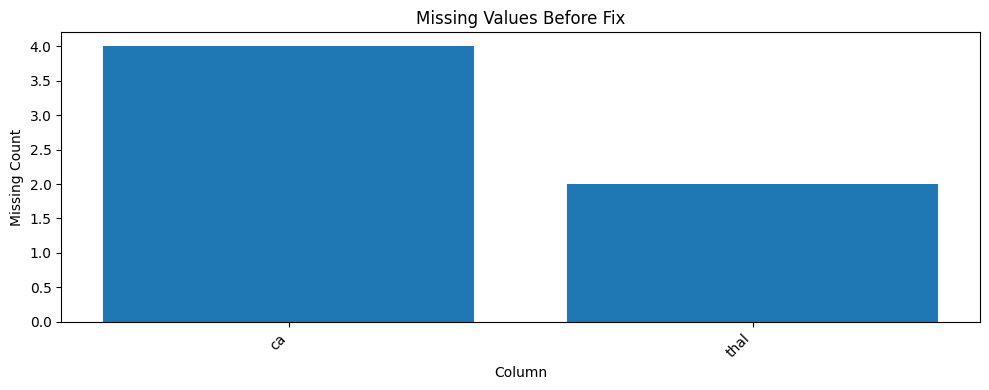

In [7]:
missing_before = df.isna().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print("===== MISSING VALUES (BEFORE FIX) =====")
if len(missing_before) == 0:
    print("No missing values.")
else:
    print(missing_before.to_string())
    plt.figure(figsize=(10,4))
    plt.bar(missing_before.index.astype(str), missing_before.values)
    plt.title("Missing Values Before Fix")
    plt.xlabel("Column")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


### Figure Explanation — Missing Values Before Fix

Biểu đồ này cho thấy cột nào có missing values và số lượng missing ở từng cột trước khi imputation.

Remaining missing after EDA fix: 0
Saved: figures\fig_2.png


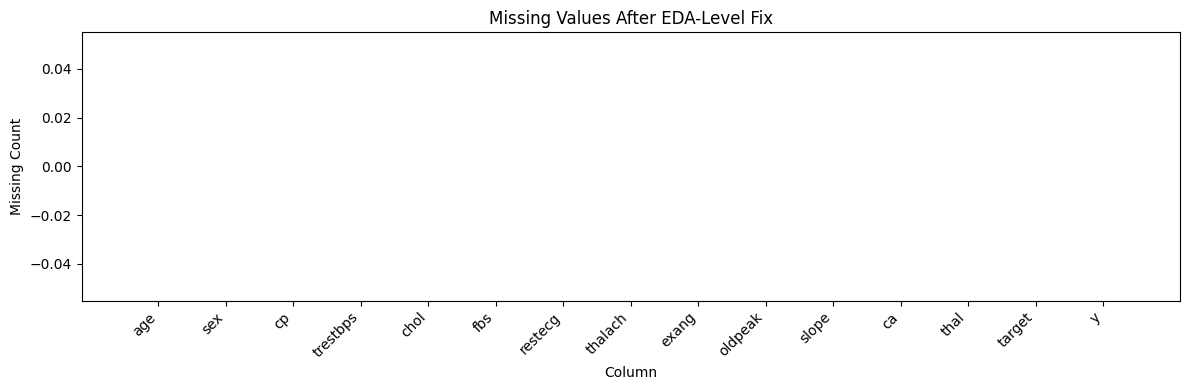

In [8]:
df_fix = df.copy()

for c in numeric_features:
    df_fix[c] = pd.to_numeric(df_fix[c], errors="coerce")
    df_fix[c] = df_fix[c].fillna(df_fix[c].median())

for c in categorical_features:
    if df_fix[c].isna().any():
        mode_val = df_fix[c].mode(dropna=True)
        df_fix[c] = df_fix[c].fillna(mode_val.iloc[0] if len(mode_val) else "Unknown")

print("Remaining missing after EDA fix:", int(df_fix.isna().sum().sum()))

plt.figure(figsize=(12,4))
plt.bar(df_fix.columns.astype(str), df_fix.isna().sum().values)
plt.title("Missing Values After EDA-Level Fix")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Figure Explanation — Missing Values After Fix

Biểu đồ này chứng minh rằng sau bước imputation tạm thời để phục vụ EDA, dữ liệu không còn missing.

## 6. Exploratory Data Analysis (EDA)

Phần này cung cấp bằng chứng trực quan về phân bố dữ liệu, outliers, tương quan, và sự khác biệt giữa các nhóm.

Saved: figures\fig_3.png


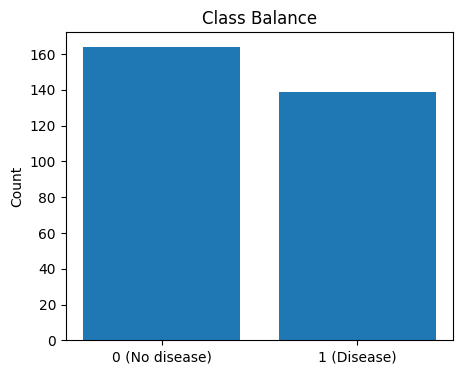

In [9]:
counts = y.value_counts().sort_index()
plt.figure(figsize=(5,4))
plt.bar(["0 (No disease)", "1 (Disease)"], counts.values)
plt.title("Class Balance")
plt.ylabel("Count")
plt.show()


### Figure Explanation — Class Balance

Biểu đồ này cho thấy tỷ lệ giữa nhóm không bệnh và có bệnh sau khi chuyển đổi nhãn nhị phân.

Saved: figures\fig_4.png


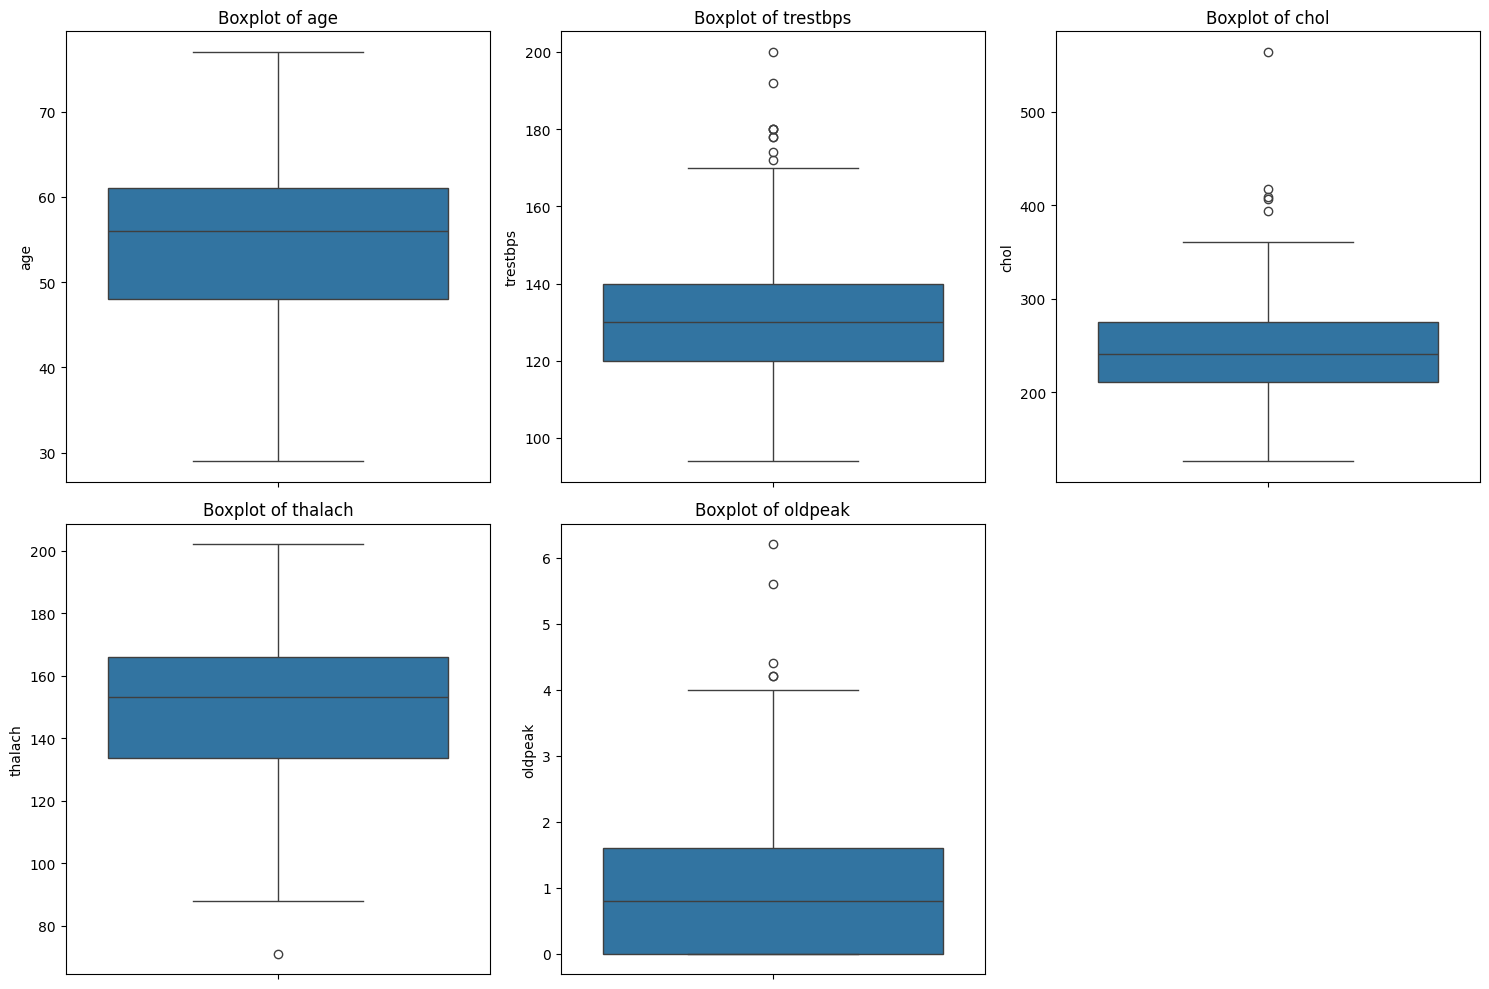

In [10]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_fix[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
plt.tight_layout()
plt.show()


### Figure Explanation — Boxplots of Numerical Features

Các boxplot cho thấy median, độ phân tán và outliers của các biến số lâm sàng.

Saved: figures\fig_5.png


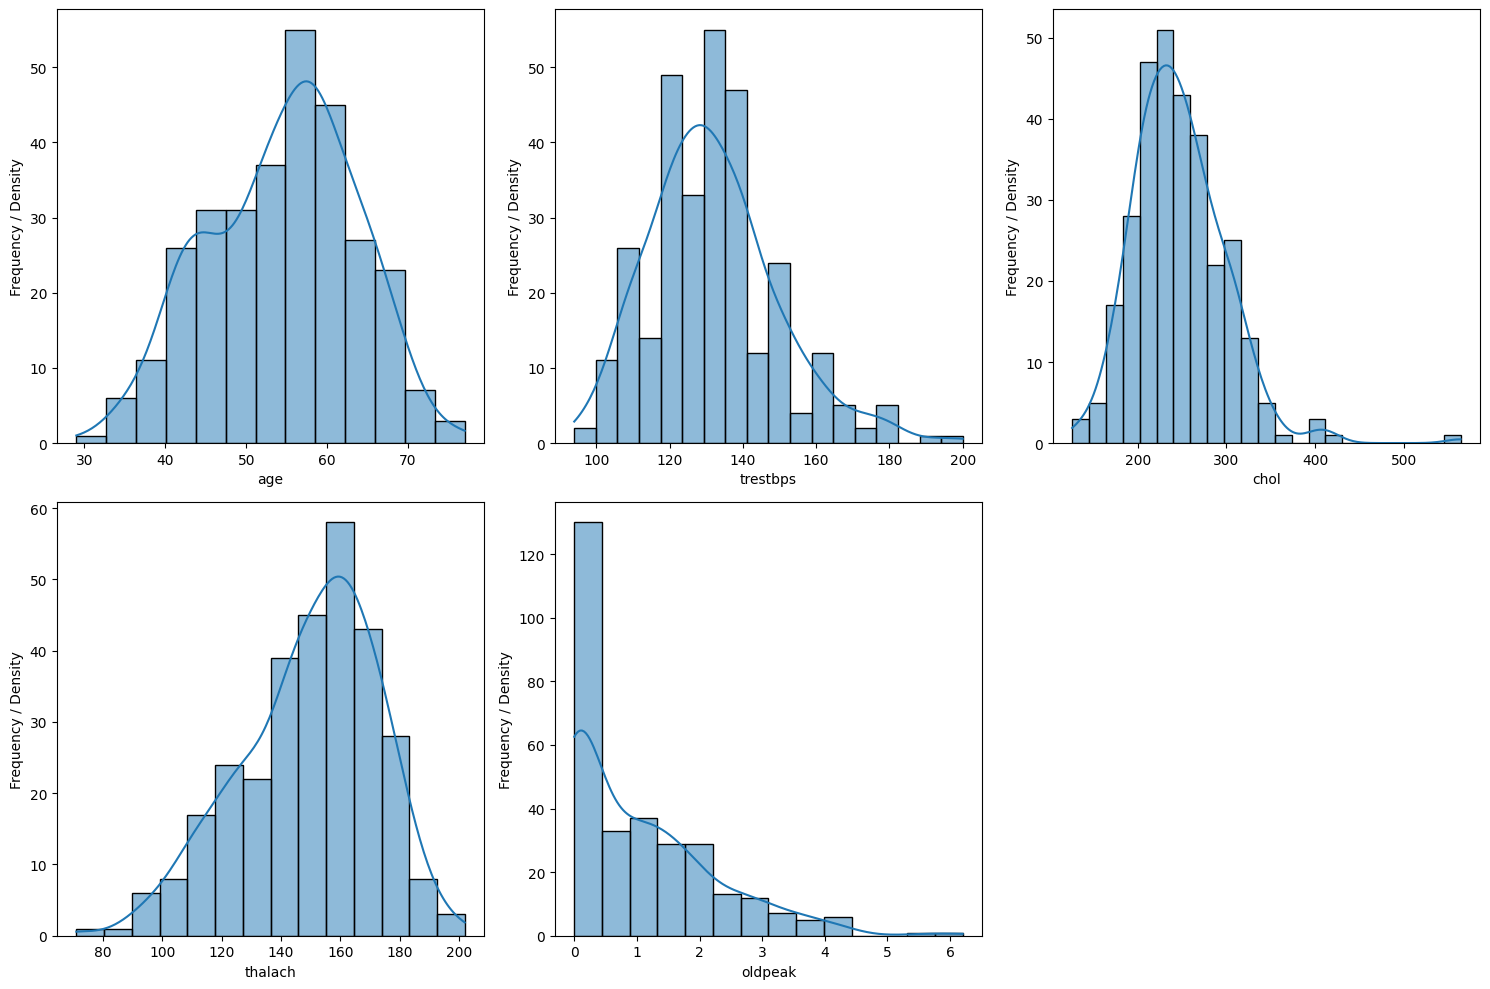

In [11]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_features):
    plt.subplot(2, 3, i+1)
    sns.histplot(df_fix[col], kde=True)
    plt.xlabel(col)
    plt.ylabel("Frequency / Density")
plt.tight_layout()
plt.show()


### Figure Explanation — Histograms and KDE

Các biểu đồ này giúp đánh giá dạng phân phối, độ lệch và tail của từng biến số.

Saved: figures\fig_6.png


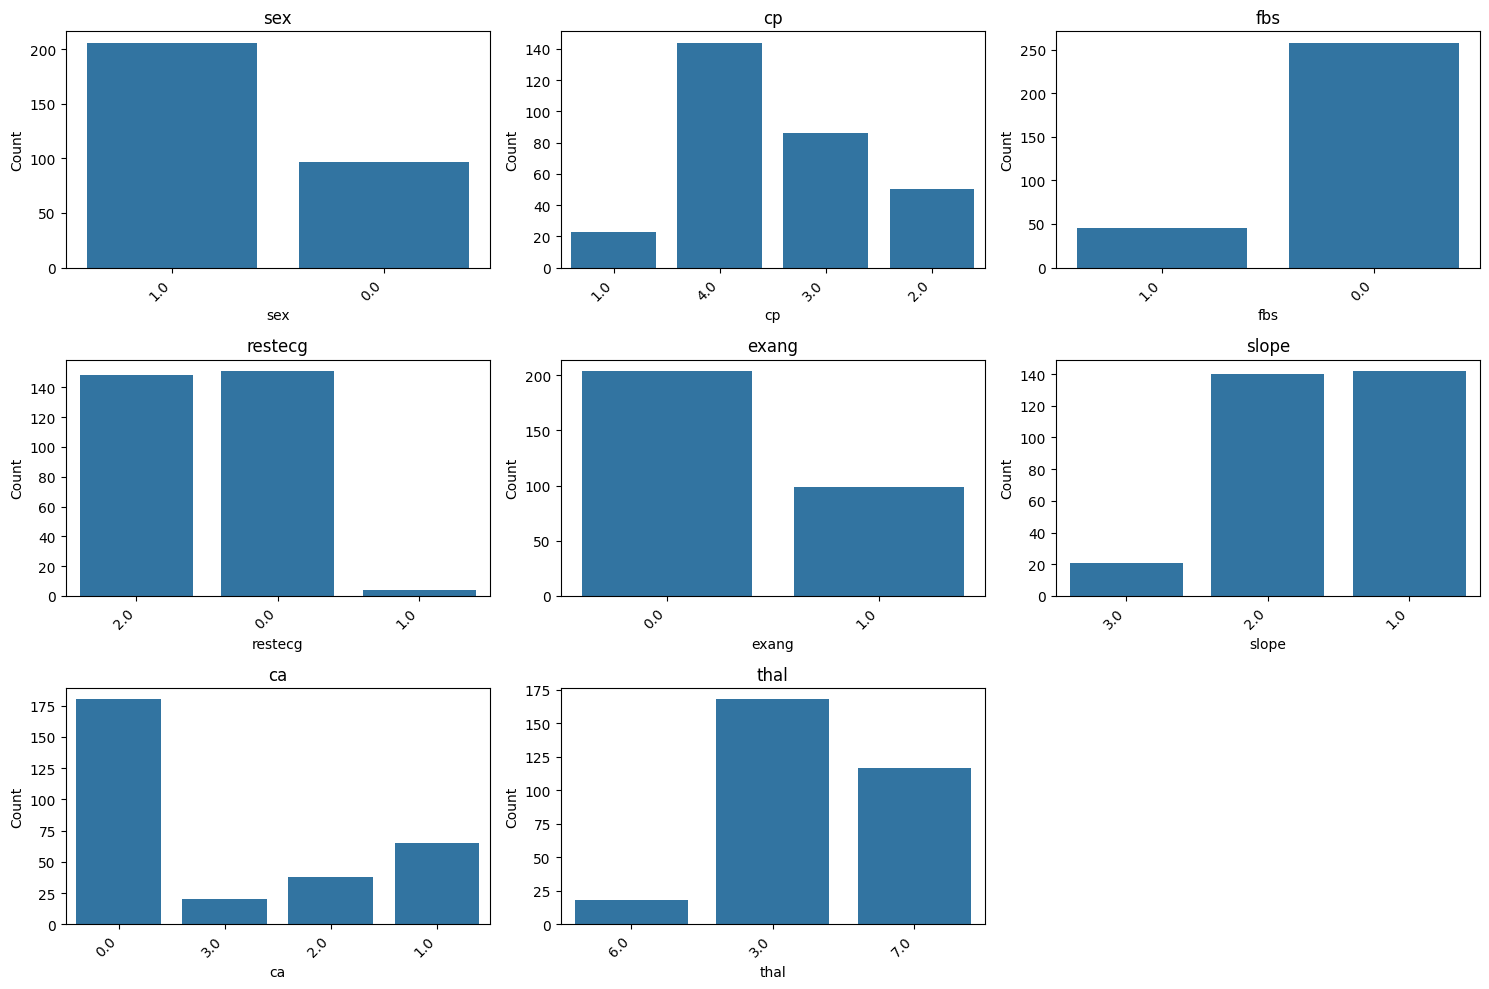

In [12]:
plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_features):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df_fix[col].astype(str))
    plt.title(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Figure Explanation — Categorical Distributions

Các countplot cho thấy phân bố của từng biến phân loại và hỗ trợ việc dùng OneHotEncoder.

Saved: figures\fig_7.png


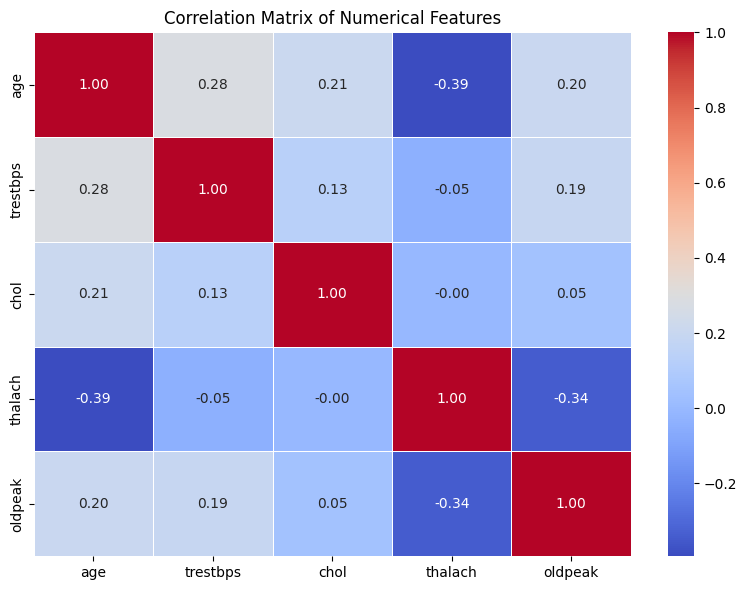

In [13]:
if len(numeric_features) >= 2:
    plt.figure(figsize=(8,6))
    sns.heatmap(df_fix[numeric_features].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Correlation Matrix of Numerical Features")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric features for correlation heatmap.")


### Figure Explanation — Correlation Matrix

Heatmap tương quan giúp đánh giá quan hệ tuyến tính giữa các biến số và nguy cơ multicollinearity.

Saved: figures\fig_8.png


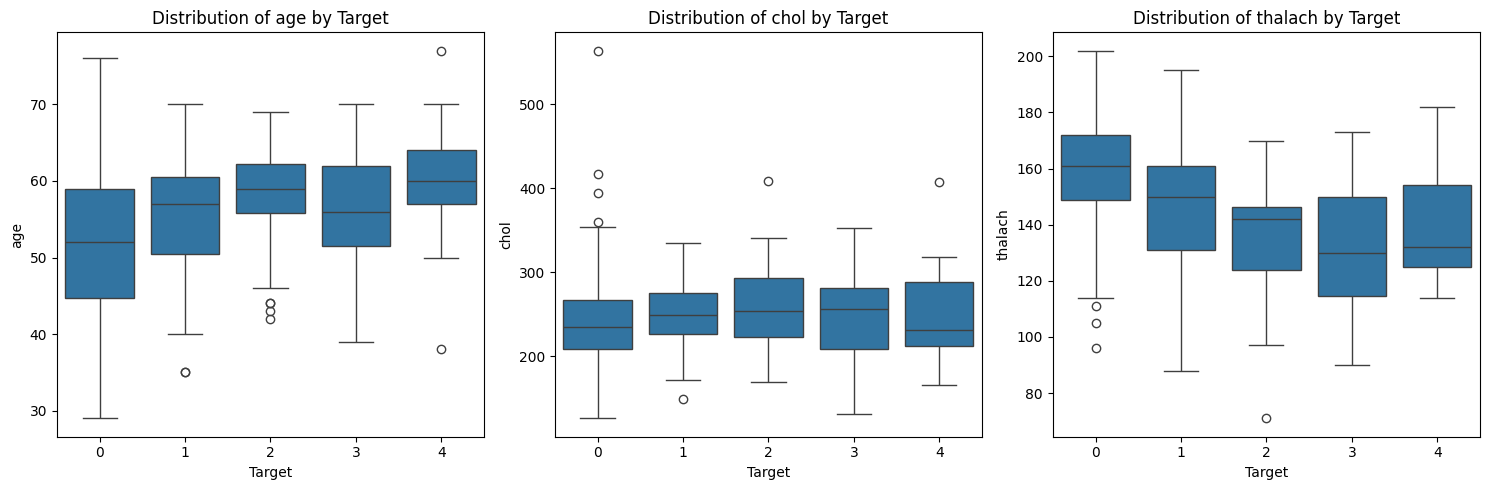

In [14]:
df_fix["target_raw"] = df_fix[target_col]
key_numerical_features = [c for c in ["age", "chol", "thalach"] if c in df_fix.columns]

if len(key_numerical_features) > 0:
    plt.figure(figsize=(15,5))
    for i, col in enumerate(key_numerical_features):
        plt.subplot(1, 3, i+1)
        sns.boxplot(x="target_raw", y=col, data=df_fix)
        plt.title(f"Distribution of {col} by Target")
        plt.xlabel("Target")
        plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### Figure Explanation — Distribution by Target

Các boxplot này minh họa cách một số biến quan trọng thay đổi theo mức độ bệnh tim gốc.

Saved: figures\fig_9.png


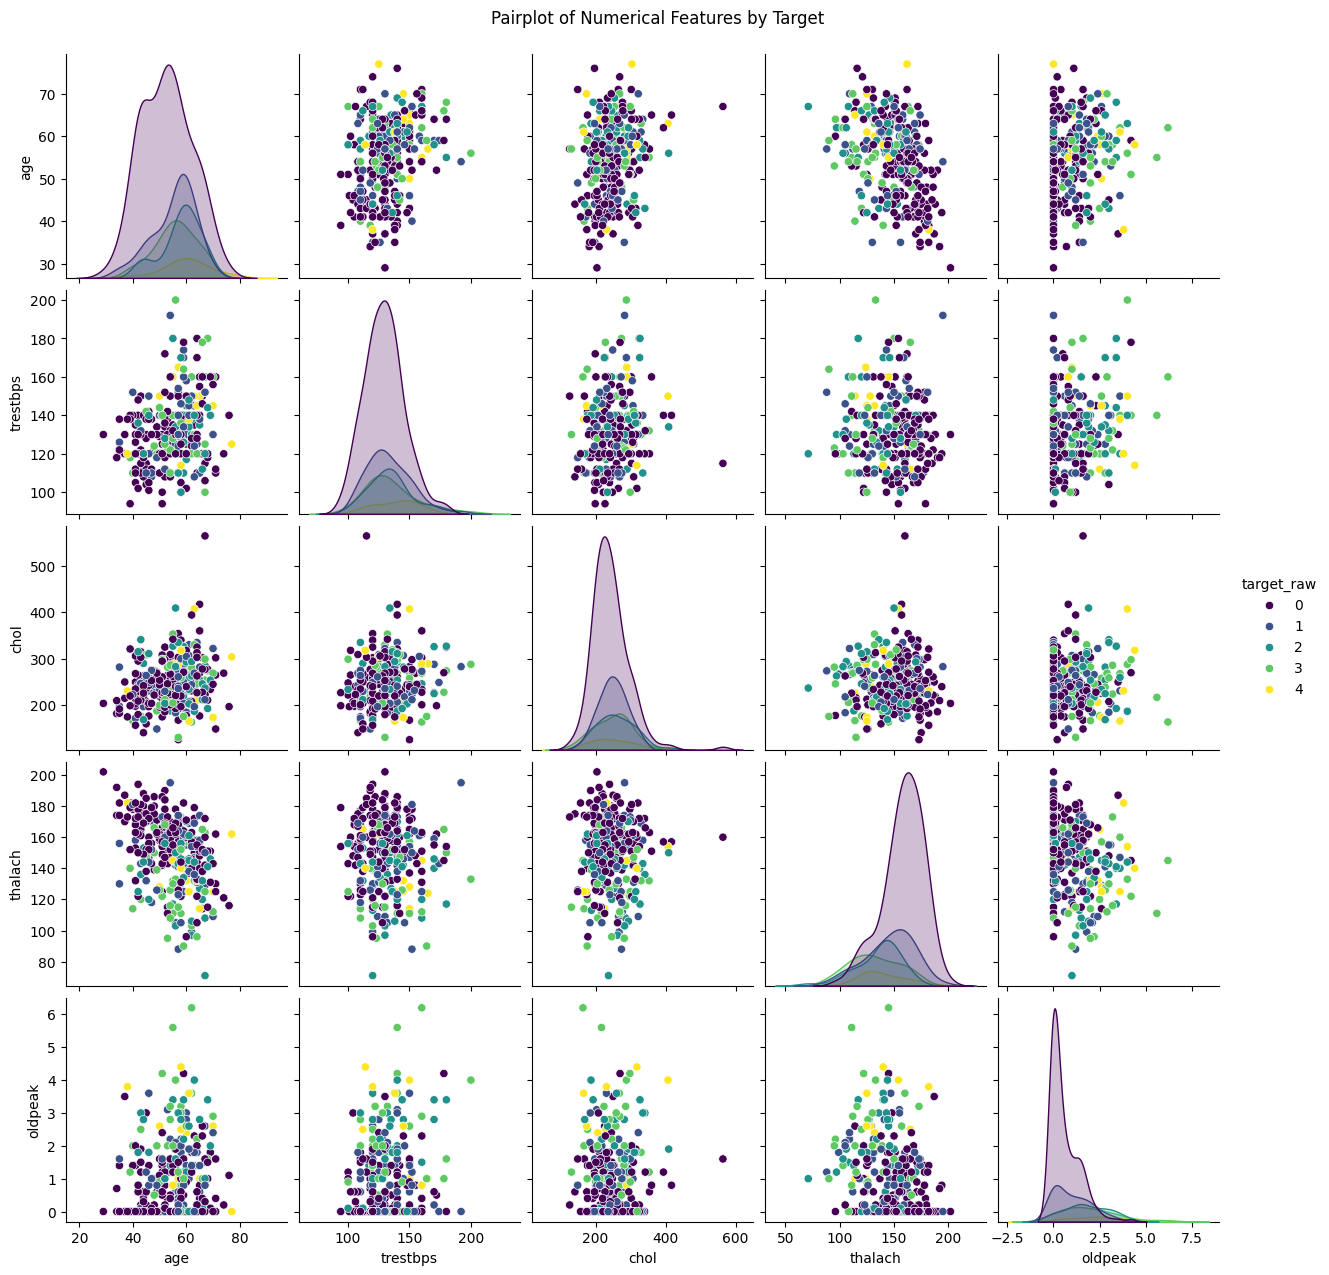

In [15]:
if len(numeric_features) >= 2:
    sns.pairplot(df_fix, vars=numeric_features, hue="target_raw", palette="viridis")
    plt.suptitle("Pairplot of Numerical Features by Target", y=1.02)
    plt.show()
else:
    print("Not enough numeric features for pairplot.")


### Figure Explanation — Pairplot

Pairplot cho phép quan sát sự chồng lấn giữa các nhóm target và hỗ trợ giải thích tại sao Logistic Regression hoặc SVC có thể phù hợp.

## 7. Train/Test Split

Dữ liệu được chia 80% train và 20% test, với `stratify=y` để giữ tỷ lệ lớp giữa train và test.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train class ratio:", y_train.value_counts(normalize=True).round(4).to_dict())
print("Test  class ratio:", y_test.value_counts(normalize=True).round(4).to_dict())


Train shape: (242, 13) | Test shape: (61, 13)
Train class ratio: {0: 0.5413, 1: 0.4587}
Test  class ratio: {0: 0.541, 1: 0.459}


## 8. Preprocessing Pipeline

Training thật sự dùng `SimpleImputer` trong Pipeline để tránh data leakage.

- Numeric: median imputation + StandardScaler
- Categorical: most_frequent imputation + OneHotEncoder

In [17]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

print("✅ Preprocessor created.")


✅ Preprocessor created.


## 9. Model Definitions

Các model gồm Majority baseline, Logistic Regression (L1/L2), và SVC (Linear/RBF).

In [18]:
models = {
    "Majority": DummyClassifier(strategy="most_frequent"),
    "LogReg_L2": LogisticRegression(penalty="l2", solver="liblinear", max_iter=2000),
    "LogReg_L1": LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000),
    "SVC_Linear": SVC(kernel="linear", C=1.0, probability=True, random_state=42),
    "SVC_RBF": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42),
}

for name, model in models.items():
    print(name, "->", model)


Majority -> DummyClassifier(strategy='most_frequent')
LogReg_L2 -> LogisticRegression(max_iter=2000, penalty='l2', solver='liblinear')
LogReg_L1 -> LogisticRegression(max_iter=2000, penalty='l1', solver='liblinear')
SVC_Linear -> SVC(kernel='linear', probability=True, random_state=42)
SVC_RBF -> SVC(probability=True, random_state=42)


## 10. Logistic Regression — Model Explanation

Logistic Regression dự đoán xác suất lớp dương bằng hàm sigmoid:

\[
P(y=1|x)=\frac{1}{1+e^{-z}}
\]

trong đó:

\[
z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n
\]

Ưu điểm: dễ diễn giải, ổn định với dataset nhỏ.

Hạn chế: giả định boundary tương đối tuyến tính.

## 11. Support Vector Classifier — Model Explanation

SVC là mô hình phân loại dựa trên maximum margin principle. SVC với kernel linear phù hợp khi dữ liệu gần tuyến tính, còn kernel RBF phù hợp khi boundary phi tuyến.

Ưu điểm: mạnh với dataset nhỏ, thường tổng quát hóa tốt.

Hạn chế: khó diễn giải hơn Logistic Regression và xác suất cần calibration nếu dùng như risk score.

# Research Question 1
## 12. Logistic Regression vs SVC — ROC-AUC / PR-AUC / F1

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
}

cv_rows = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model),
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    cv_rows.append({
        "Model": name,
        "ROC-AUC mean": np.mean(scores["test_roc_auc"]),
        "ROC-AUC std": np.std(scores["test_roc_auc"]),
        "PR-AUC mean": np.mean(scores["test_pr_auc"]),
        "PR-AUC std": np.std(scores["test_pr_auc"]),
        "F1 mean": np.mean(scores["test_f1"]),
        "F1 std": np.std(scores["test_f1"]),
    })

cv_results = pd.DataFrame(cv_rows).sort_values(by="ROC-AUC mean", ascending=False)
print("===== CROSS-VALIDATION RESULTS =====")
print(cv_results.to_string(index=False))


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re

===== CROSS-VALIDATION RESULTS =====
     Model  ROC-AUC mean  ROC-AUC std  PR-AUC mean  PR-AUC std  F1 mean   F1 std
 LogReg_L1      0.920145     0.019095     0.918604    0.023685 0.841028 0.060666
 LogReg_L2      0.918796     0.020713     0.917827    0.026155 0.833226 0.057909
SVC_Linear      0.908176     0.017436     0.911808    0.025455 0.819771 0.054851
   SVC_RBF      0.902143     0.028568     0.903582    0.036039 0.826106 0.050742
  Majority      0.500000     0.000000     0.458743    0.005281 0.000000 0.000000


### Interpretation of CV Results

Bảng này cho phép so sánh độ ổn định giữa các mô hình thông qua mean và std của ROC-AUC, PR-AUC và F1.

In [20]:
trained_pipelines = {}
test_rows = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_score = pipe.predict_proba(X_test)[:, 1]

    test_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "PR-AUC": average_precision_score(y_test, y_score),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
    })
    trained_pipelines[name] = pipe

test_results = pd.DataFrame(test_rows).sort_values(by="ROC-AUC", ascending=False)
print("===== TEST RESULTS =====")
print(test_results.to_string(index=False))


===== TEST RESULTS =====
     Model  Accuracy  ROC-AUC   PR-AUC       F1  Precision   Recall
 LogReg_L2  0.885246 0.966450 0.963435 0.881356   0.838710 0.928571
   SVC_RBF  0.885246 0.964286 0.955836 0.881356   0.838710 0.928571
SVC_Linear  0.852459 0.961039 0.957194 0.852459   0.787879 0.928571
 LogReg_L1  0.868852 0.958874 0.954618 0.862069   0.833333 0.892857
  Majority  0.540984 0.500000 0.459016 0.000000   0.000000 0.000000


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penal

### Interpretation of Test Results

Bảng test results giúp trả lời trực tiếp mô hình nào mạnh hơn trên tập test về AUC, PR-AUC và F1.

Saved: figures\fig_10.png


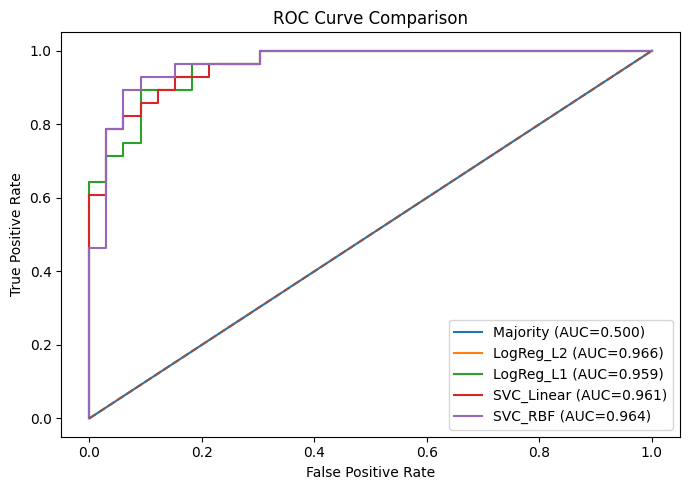

In [21]:
plt.figure(figsize=(7,5))
for name, pipe in trained_pipelines.items():
    y_score = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


### Figure Explanation — ROC Curve Comparison

ROC curve dùng để đánh giá khả năng phân biệt hai lớp của các mô hình trên mọi ngưỡng. Đường càng gần góc trên bên trái và AUC càng cao thì mô hình càng tốt.

Saved: figures\fig_11.png


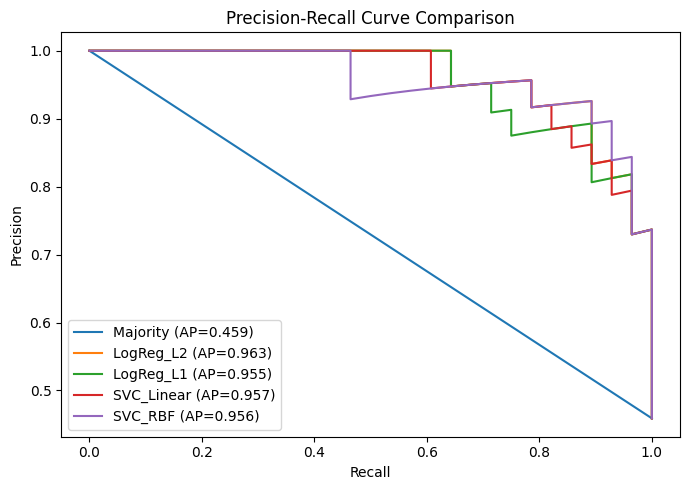

In [22]:
plt.figure(figsize=(7,5))
for name, pipe in trained_pipelines.items():
    y_score = pipe.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()


### Figure Explanation — Precision-Recall Curve

PR curve đặc biệt quan trọng trong bài toán y tế khi lớp dương cần được chú ý nhiều hơn.

## PR-AUC (Average Precision) Summary

Besides plotting the Precision–Recall curve, this section reports the **Average Precision (AP)** value explicitly for each model.  
This addresses the limitation of reporting only curves without numerical PR-AUC evidence.


In [23]:
# Explicit AP / PR-AUC table for each model
ap_rows = []
for name, pipe in trained_pipelines.items():
    y_prob_tmp = pipe.predict_proba(X_test)[:, 1]
    ap_rows.append({
        "Model": name,
        "PR-AUC (AP)": average_precision_score(y_test, y_prob_tmp)
    })

ap_results = pd.DataFrame(ap_rows).sort_values(by="PR-AUC (AP)", ascending=False)
print("===== PR-AUC / AVERAGE PRECISION RESULTS =====")
print(ap_results.to_string(index=False))


===== PR-AUC / AVERAGE PRECISION RESULTS =====
     Model  PR-AUC (AP)
 LogReg_L2     0.963435
SVC_Linear     0.957194
   SVC_RBF     0.955836
 LogReg_L1     0.954618
  Majority     0.459016


### Interpretation of PR-AUC Results

This table reports **Average Precision (AP)** for each classifier.  
A higher AP indicates stronger performance on the positive class and is especially important in medical datasets where correctly identifying disease cases is critical.


# Research Question 2
## 13. Threshold Analysis

In [24]:
logreg_main = trained_pipelines["LogReg_L2"]
y_score_lr = logreg_main.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)
rows = []

for th in thresholds:
    y_pred_th = (y_score_lr >= th).astype(int)
    rows.append({
        "threshold": th,
        "precision": precision_score(y_test, y_pred_th, zero_division=0),
        "recall": recall_score(y_test, y_pred_th, zero_division=0),
        "f1": f1_score(y_test, y_pred_th, zero_division=0),
    })

threshold_df = pd.DataFrame(rows)
print(threshold_df.to_string(index=False))


 threshold  precision   recall       f1
      0.10   0.636364 1.000000 0.777778
      0.15   0.682927 1.000000 0.811594
      0.20   0.700000 1.000000 0.823529
      0.25   0.736842 1.000000 0.848485
      0.30   0.729730 0.964286 0.830769
      0.35   0.818182 0.964286 0.885246
      0.40   0.818182 0.964286 0.885246
      0.45   0.812500 0.928571 0.866667
      0.50   0.838710 0.928571 0.881356
      0.55   0.862069 0.892857 0.877193
      0.60   0.862069 0.892857 0.877193
      0.65   0.892857 0.892857 0.892857
      0.70   0.923077 0.857143 0.888889
      0.75   0.956522 0.785714 0.862745
      0.80   0.954545 0.750000 0.840000
      0.85   0.947368 0.642857 0.765957
      0.90   1.000000 0.607143 0.755556


Saved: figures\fig_12.png


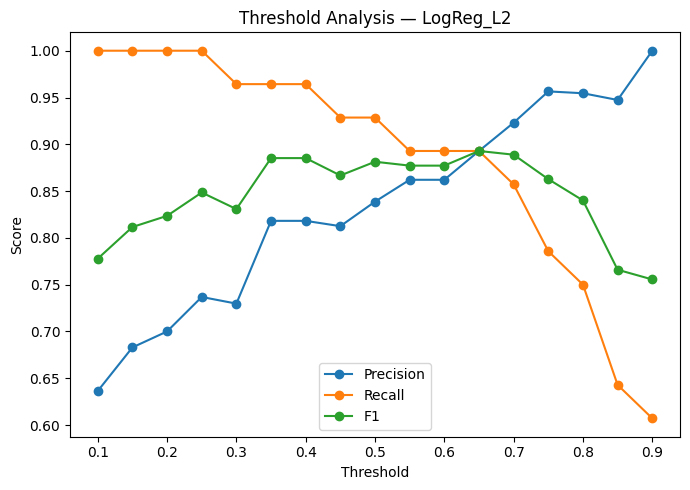

In [25]:
plt.figure(figsize=(7,5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.title("Threshold Analysis — LogReg_L2")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


### Figure Explanation — Threshold Trade-off

Biểu đồ này chứng minh rằng threshold thấp làm tăng recall, còn threshold cao làm tăng precision. F1 thường đạt tốt nhất ở một số ngưỡng trung gian.

Saved: figures\fig_13.png


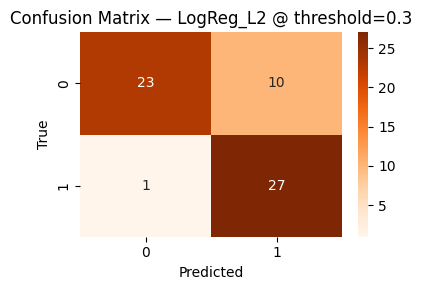

Saved: figures\fig_14.png


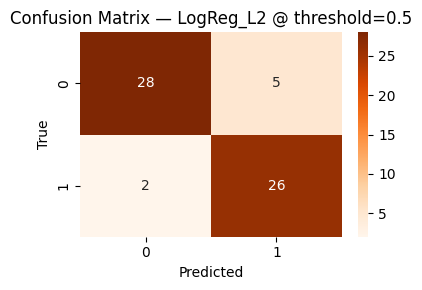

Saved: figures\fig_15.png


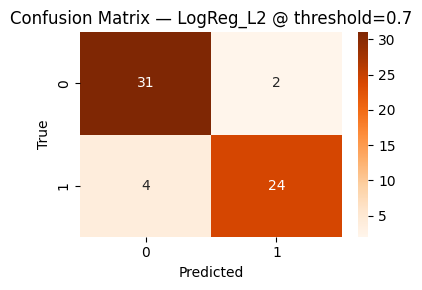

In [26]:
for th in [0.3, 0.5, 0.7]:
    y_pred_th = (y_score_lr >= th).astype(int)
    cm = confusion_matrix(y_test, y_pred_th)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
    plt.title(f"Confusion Matrix — LogReg_L2 @ threshold={th}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


### Figure Explanation — Confusion Matrix at Different Thresholds

Các confusion matrix này cho thấy số TP, FP, TN, FN thay đổi như thế nào khi threshold thay đổi.

## Threshold Tuning Table

To make threshold optimization more transparent, the notebook now reports a **threshold tuning table** at selected operating points.
In addition to Precision, Recall, and F1-score, a simple **cost** function is included.

The cost is defined as:

\[
\mathrm{Cost} = c_{FP}\cdot FP + c_{FN}\cdot FN
\]

where:
- \(c_{FP}\) is the cost assigned to a false positive
- \(c_{FN}\) is the cost assigned to a false negative

For medical screening, false negatives are often more harmful, so \(c_{FN}\) is usually set higher than \(c_{FP}\).


In [27]:
# Threshold tuning table with explicit cost
FP_COST = 1
FN_COST = 5   # false negatives penalized more strongly in medical screening

selected_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_tuning_rows = []

for th in selected_thresholds:
    y_pred_th = (y_score_lr >= th).astype(int)
    cm_sel = confusion_matrix(y_test, y_pred_th)
    tn, fp, fn, tp = cm_sel.ravel()

    threshold_tuning_rows.append({
        "threshold": th,
        "precision": precision_score(y_test, y_pred_th, zero_division=0),
        "recall": recall_score(y_test, y_pred_th, zero_division=0),
        "f1": f1_score(y_test, y_pred_th, zero_division=0),
        "fp": fp,
        "fn": fn,
        "cost": FP_COST * fp + FN_COST * fn
    })

threshold_tuning_df = pd.DataFrame(threshold_tuning_rows)
print("===== THRESHOLD TUNING TABLE =====")
print(threshold_tuning_df.to_string(index=False))


===== THRESHOLD TUNING TABLE =====
 threshold  precision   recall       f1  fp  fn  cost
       0.3   0.729730 0.964286 0.830769  10   1    15
       0.4   0.818182 0.964286 0.885246   6   1    11
       0.5   0.838710 0.928571 0.881356   5   2    15
       0.6   0.862069 0.892857 0.877193   4   3    19
       0.7   0.923077 0.857143 0.888889   2   4    22


### Interpretation of Threshold Tuning

This table makes threshold selection more operational:
- lower thresholds usually improve **recall**
- higher thresholds usually improve **precision**
- the **cost column** helps select thresholds under asymmetric medical risk assumptions


# Research Question 3
## 14. Calibration Analysis

Saved: figures\fig_16.png


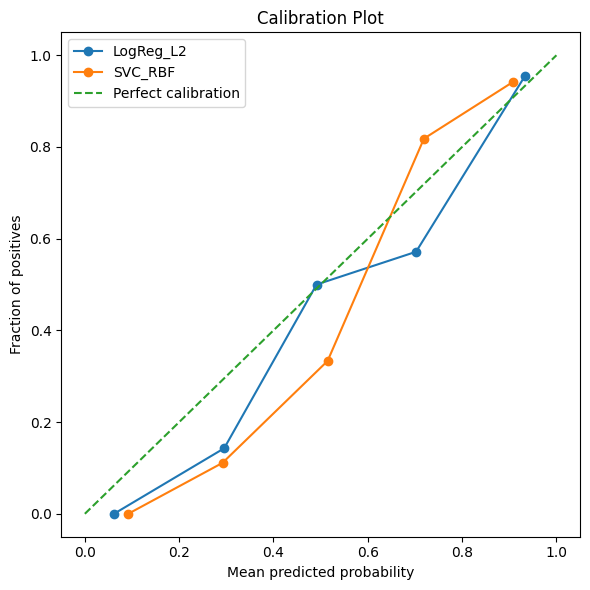

In [28]:
models_for_calibration = ["LogReg_L2", "SVC_RBF"]

plt.figure(figsize=(6,6))
for name in models_for_calibration:
    pipe = trained_pipelines[name]
    y_prob = pipe.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=5)
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.title("Calibration Plot")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend()
plt.tight_layout()
plt.show()


### Figure Explanation — Calibration Plot

Calibration plot cho biết xác suất đầu ra của mô hình có gần với tần suất dương tính thực tế hay không, từ đó đánh giá khả năng dùng probability như risk score.

## Quantitative Calibration Metrics

Visual calibration curves are useful, but they should be complemented by **quantitative calibration metrics**.

This section reports:
- **Brier Score**
- **Log Loss**
- **Expected Calibration Error (ECE)**

A lower value indicates better calibration quality.


In [29]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    rows = []

    for i in range(n_bins):
        mask = bin_ids == i
        if np.sum(mask) > 0:
            bin_acc = np.mean(y_true[mask])
            bin_conf = np.mean(y_prob[mask])
            bin_size = np.sum(mask)
            gap = abs(bin_acc - bin_conf)
            ece += (bin_size / len(y_true)) * gap

            rows.append({
                "bin": i,
                "count": int(bin_size),
                "mean_pred_prob": float(bin_conf),
                "actual_positive_rate": float(bin_acc),
                "abs_gap": float(gap),
            })

    return ece, pd.DataFrame(rows)


In [30]:
calibration_rows = []

for name, pipe in trained_pipelines.items():
    y_prob_tmp = pipe.predict_proba(X_test)[:, 1]
    ece_val, _ = expected_calibration_error(y_test, y_prob_tmp, n_bins=10)

    calibration_rows.append({
        "Model": name,
        "Brier Score": brier_score_loss(y_test, y_prob_tmp),
        "Log Loss": log_loss(y_test, y_prob_tmp),
        "ECE": ece_val
    })

calibration_metrics_df = pd.DataFrame(calibration_rows).sort_values(by="Brier Score")
print("===== QUANTITATIVE CALIBRATION METRICS =====")
print(calibration_metrics_df.to_string(index=False))


===== QUANTITATIVE CALIBRATION METRICS =====
     Model  Brier Score  Log Loss      ECE
 LogReg_L2     0.079737  0.259499 0.082536
 LogReg_L1     0.083293  0.272178 0.097331
   SVC_RBF     0.086401  0.299525 0.108663
SVC_Linear     0.089112  0.298365 0.108011
  Majority     0.459016 16.544628 0.459016


### Reliability Diagram by Bin

To provide more detailed calibration evidence, the following table reports **bin-level reliability information** for the main Logistic Regression model.


In [31]:
# Reliability table for main Logistic Regression model
y_prob_lr_reliability = trained_pipelines["LogReg_L2"].predict_proba(X_test)[:, 1]
ece_lr, reliability_lr_df = expected_calibration_error(y_test, y_prob_lr_reliability, n_bins=10)

print("ECE (LogReg_L2):", round(ece_lr, 6))
print(reliability_lr_df.to_string(index=False))


ECE (LogReg_L2): 0.082536
 bin  count  mean_pred_prob  actual_positive_rate  abs_gap
   0     17        0.041523              0.000000 0.041523
   1      4        0.147945              0.000000 0.147945
   2      3        0.236457              0.333333 0.096876
   3      4        0.339655              0.000000 0.339655
   4      2        0.462433              0.500000 0.037567
   5      2        0.520359              0.500000 0.020359
   6      3        0.663522              0.333333 0.330189
   7      4        0.731479              0.750000 0.018521
   8      5        0.843608              0.800000 0.043608
   9     17        0.959458              1.000000 0.040542


### Added Note — Platt Scaling in this notebook

This updated notebook explicitly includes **Platt scaling** for probability calibration using:

```python
CalibratedClassifierCV(..., method="sigmoid", cv=5)
```

In this notebook:
- `method="sigmoid"` = **Platt Scaling**
- `method="isotonic"` = **Isotonic Regression**

The main implementation is in the next code cell under **Calibration Improvement: Platt Scaling and Isotonic Regression**.

## Calibration Improvement: Platt Scaling and Isotonic Regression

To strengthen deployment-oriented reliability, calibration is improved using:
- **Platt scaling** (`sigmoid`)
- **Isotonic regression**

These methods are applied to compare original versus calibrated probability outputs.


In [32]:
# Base models for calibration comparison
logreg_base = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(penalty="l2", solver="liblinear", max_iter=2000))
])

svc_base = Pipeline([
    ("preprocess", preprocessor),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=False, random_state=42))
])

logreg_platt = CalibratedClassifierCV(logreg_base, method="sigmoid", cv=5)
logreg_isotonic = CalibratedClassifierCV(logreg_base, method="isotonic", cv=5)

svc_platt = CalibratedClassifierCV(svc_base, method="sigmoid", cv=5)
svc_isotonic = CalibratedClassifierCV(svc_base, method="isotonic", cv=5)

logreg_platt.fit(X_train, y_train)
logreg_isotonic.fit(X_train, y_train)
svc_platt.fit(X_train, y_train)
svc_isotonic.fit(X_train, y_train)


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocess',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['age',
                                                                                    'trestbps',
                                                                                    'chol',
                                                             

In [33]:
models_calibrated = {
    "LogReg_Original": trained_pipelines["LogReg_L2"],
    "LogReg_Platt": logreg_platt,
    "LogReg_Isotonic": logreg_isotonic,
    "SVC_Original": trained_pipelines["SVC_RBF"],
    "SVC_Platt": svc_platt,
    "SVC_Isotonic": svc_isotonic,
}

calibration_compare_rows = []

for name, model in models_calibrated.items():
    y_prob_tmp = model.predict_proba(X_test)[:, 1]
    ece_val, _ = expected_calibration_error(y_test, y_prob_tmp, n_bins=10)
    calibration_compare_rows.append({
        "Model": name,
        "PR-AUC (AP)": average_precision_score(y_test, y_prob_tmp),
        "Brier Score": brier_score_loss(y_test, y_prob_tmp),
        "Log Loss": log_loss(y_test, y_prob_tmp),
        "ECE": ece_val
    })

calibration_compare_df = pd.DataFrame(calibration_compare_rows).sort_values(by="Brier Score")
print("===== CALIBRATION COMPARISON =====")
print(calibration_compare_df.to_string(index=False))


===== CALIBRATION COMPARISON =====
          Model  PR-AUC (AP)  Brier Score  Log Loss      ECE
LogReg_Isotonic     0.964673     0.079703  0.254182 0.090696
LogReg_Original     0.963435     0.079737  0.259499 0.082536
   LogReg_Platt     0.964434     0.084768  0.292643 0.101493
   SVC_Isotonic     0.954070     0.085973  0.289484 0.095917
   SVC_Original     0.955836     0.086401  0.299525 0.108663
      SVC_Platt     0.952016     0.093314  0.327315 0.150847


Saved: figures\fig_17.png


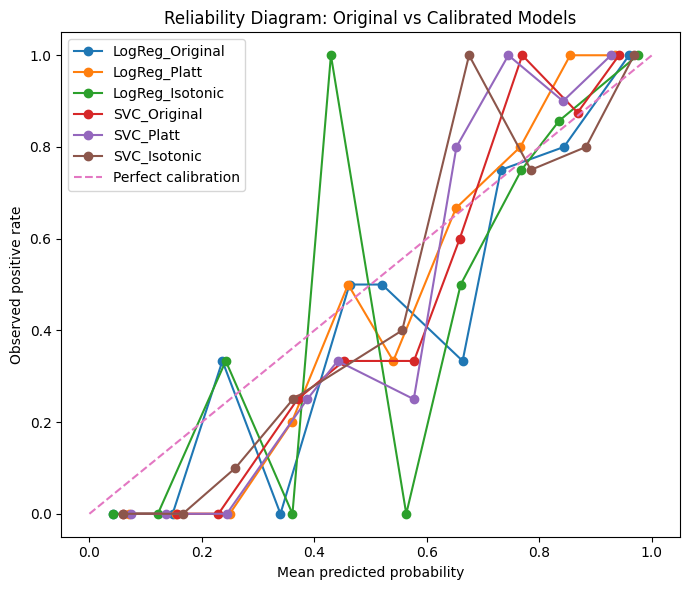

In [34]:
plt.figure(figsize=(7,6))

for name in ["LogReg_Original", "LogReg_Platt", "LogReg_Isotonic",
             "SVC_Original", "SVC_Platt", "SVC_Isotonic"]:
    y_prob_tmp = models_calibrated[name].predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_prob_tmp, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Reliability Diagram: Original vs Calibrated Models")
plt.legend()
plt.tight_layout()
plt.show()


## 15. Logistic Regression Interpretability

Logistic Regression có ưu điểm lớn về interpretability. Coefficient dương làm tăng nguy cơ, coefficient âm làm giảm nguy cơ. Có thể chuyển coefficient sang odds ratio qua công thức `exp(coef)`.

In [35]:
pre = trained_pipelines["LogReg_L2"].named_steps["preprocess"]

feature_names = []
feature_names.extend(numeric_features)

if len(categorical_features) > 0:
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    feature_names.extend(list(ohe.get_feature_names_out(categorical_features)))

coef = trained_pipelines["LogReg_L2"].named_steps["model"].coef_.ravel()
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "odds_ratio": np.exp(coef),
}).sort_values("coef", ascending=False)

print("Top positive coefficients:")
print(coef_df.head(15).to_string(index=False))

print("\nTop negative coefficients:")
print(coef_df.tail(15).to_string(index=False))


Top positive coefficients:
    feature      coef  odds_ratio
     cp_4.0  1.029376    2.799318
   thal_7.0  0.816355    2.262238
    sex_1.0  0.687775    1.989284
     ca_2.0  0.641969    1.900219
  slope_2.0  0.602045    1.825850
     ca_3.0  0.492857    1.636986
     ca_1.0  0.350673    1.420023
   trestbps  0.340511    1.405666
    oldpeak  0.260193    1.297180
  exang_1.0  0.258041    1.294391
restecg_2.0  0.213585    1.238108
       chol  0.178925    1.195930
     cp_2.0  0.153498    1.165905
    fbs_0.0  0.091039    1.095312
        age -0.061535    0.940320

Top negative coefficients:
    feature      coef  odds_ratio
    fbs_0.0  0.091039    1.095312
        age -0.061535    0.940320
restecg_1.0 -0.072040    0.930494
    fbs_1.0 -0.105318    0.900039
restecg_0.0 -0.155823    0.855711
  slope_3.0 -0.175154    0.839327
  exang_0.0 -0.272319    0.761611
   thal_6.0 -0.287340    0.750256
    thalach -0.372224    0.689200
  slope_1.0 -0.441169    0.643284
   thal_3.0 -0.543293    0.

Saved: figures\fig_18.png


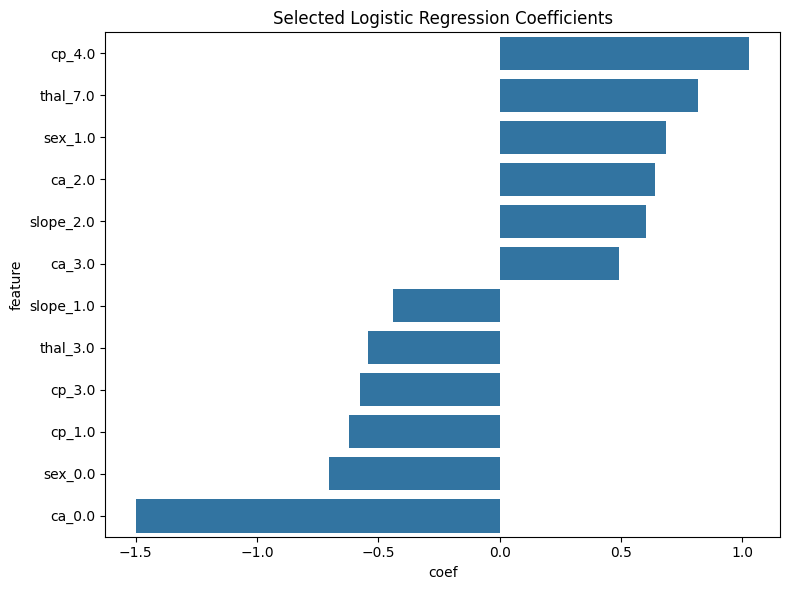

In [36]:
top_show = 12
coef_plot = pd.concat([coef_df.head(top_show//2), coef_df.tail(top_show//2)])

plt.figure(figsize=(8,6))
sns.barplot(data=coef_plot, x="coef", y="feature")
plt.title("Selected Logistic Regression Coefficients")
plt.tight_layout()
plt.show()


### Figure Explanation — Logistic Regression Coefficients

Biểu đồ coefficients là bằng chứng trực tiếp cho phần interpretability: mô hình không chỉ dự đoán mà còn giải thích yếu tố làm tăng/giảm nguy cơ.

## 16. Classification Report and Confusion Matrix

Phần này tổng hợp precision, recall, F1-score và confusion matrix cho từng mô hình.


===== Majority =====
              precision    recall  f1-score   support

           0       0.54      1.00      0.70        33
           1       0.00      0.00      0.00        28

    accuracy                           0.54        61
   macro avg       0.27      0.50      0.35        61
weighted avg       0.29      0.54      0.38        61

Confusion Matrix:
[[33  0]
 [28  0]]
Saved: figures\fig_19.png


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

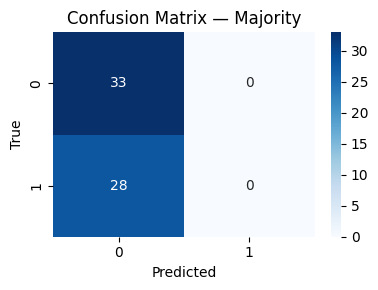


===== LogReg_L2 =====
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

Confusion Matrix:
[[28  5]
 [ 2 26]]
Saved: figures\fig_20.png


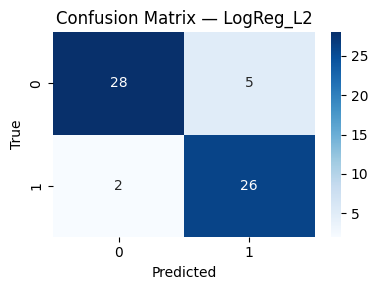


===== LogReg_L1 =====
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

Confusion Matrix:
[[28  5]
 [ 3 25]]
Saved: figures\fig_21.png


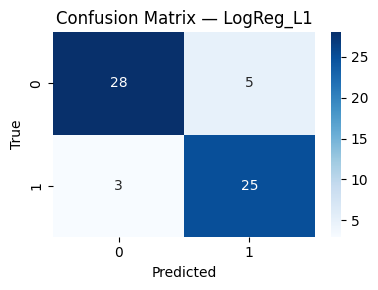


===== SVC_Linear =====
              precision    recall  f1-score   support

           0       0.93      0.79      0.85        33
           1       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61

Confusion Matrix:
[[26  7]
 [ 2 26]]
Saved: figures\fig_22.png


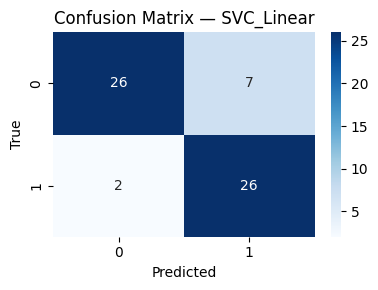


===== SVC_RBF =====
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

Confusion Matrix:
[[28  5]
 [ 2 26]]
Saved: figures\fig_23.png


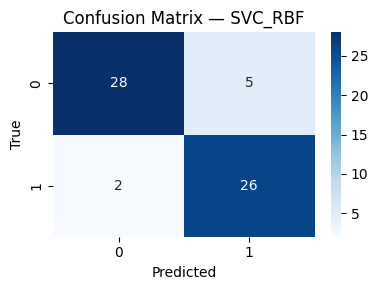

In [37]:
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


### Figure Explanation — Confusion Matrix for Each Model

Mỗi confusion matrix cho thấy mô hình đang bỏ sót bệnh hay báo nhầm bệnh nhiều hơn, từ đó hỗ trợ so sánh precision/recall giữa các mô hình.

## 17. Best Model Summary

Phần này xác định mô hình tốt nhất theo ROC-AUC và F1.

In [38]:
best_by_auc = test_results.sort_values(by="ROC-AUC", ascending=False).iloc[0]
best_by_f1  = test_results.sort_values(by="F1", ascending=False).iloc[0]

print("Best by ROC-AUC:")
print(best_by_auc.to_string())

print("\nBest by F1:")
print(best_by_f1.to_string())


Best by ROC-AUC:
Model        LogReg_L2
Accuracy      0.885246
ROC-AUC        0.96645
PR-AUC        0.963435
F1            0.881356
Precision      0.83871
Recall        0.928571

Best by F1:
Model        LogReg_L2
Accuracy      0.885246
ROC-AUC        0.96645
PR-AUC        0.963435
F1            0.881356
Precision      0.83871
Recall        0.928571


## 17A. 95% Confidence Interval for AUC (Bootstrap)

To quantify uncertainty, this notebook estimates a **95% confidence interval (CI)** for ROC-AUC using bootstrap resampling.


In [39]:
def bootstrap_auc_ci(y_true, y_prob, n_bootstrap=2000, ci=95, random_state=42):
    rng = np.random.RandomState(random_state)
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    auc_scores = []
    n = len(y_true)

    for _ in range(n_bootstrap):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        auc_scores.append(roc_auc_score(y_true[idx], y_prob[idx]))

    lower = np.percentile(auc_scores, (100 - ci) / 2)
    upper = np.percentile(auc_scores, 100 - (100 - ci) / 2)
    return np.mean(auc_scores), lower, upper


In [40]:
auc_ci_rows = []

for name, pipe in trained_pipelines.items():
    y_prob_tmp = pipe.predict_proba(X_test)[:, 1]
    auc_mean, auc_low, auc_high = bootstrap_auc_ci(y_test, y_prob_tmp, n_bootstrap=2000, ci=95, random_state=42)

    auc_ci_rows.append({
        "Model": name,
        "AUC_bootstrap_mean": auc_mean,
        "AUC_95CI_lower": auc_low,
        "AUC_95CI_upper": auc_high
    })

auc_ci_df = pd.DataFrame(auc_ci_rows).sort_values(by="AUC_bootstrap_mean", ascending=False)
print("===== BOOTSTRAP 95% CI FOR AUC =====")
print(auc_ci_df.to_string(index=False))


===== BOOTSTRAP 95% CI FOR AUC =====
     Model  AUC_bootstrap_mean  AUC_95CI_lower  AUC_95CI_upper
 LogReg_L2            0.966139        0.923077        0.994444
   SVC_RBF            0.963848        0.912902        0.995699
SVC_Linear            0.960644        0.911762        0.992376
 LogReg_L1            0.958471        0.910981        0.989515
  Majority            0.500000        0.500000        0.500000


## 17B. Code Availability and Reproducibility

To support reproducible research, this project should report:
- the **GitHub repository link**
- package versions
- the fixed random seed
- data source reference
- export files for figures and tables

### Reproducibility checklist
- `random_state = 42`
- stratified train/test split
- stratified 5-fold cross-validation
- notebook-based execution
- Excel export for all major numerical results

### GitHub placeholder
Replace the placeholder below with your actual repository:

`GitHub Repository: https://github.com/your-username/heart-disease-risk-prediction`


In [41]:
# Reproducibility info
import platform
import sklearn
import matplotlib
import seaborn

reproducibility_df = pd.DataFrame({
    "item": [
        "Python version",
        "Platform",
        "NumPy version",
        "Pandas version",
        "Scikit-learn version",
        "Matplotlib version",
        "Seaborn version",
        "Random seed",
        "Train/Test split",
        "Cross-validation"
    ],
    "value": [
        sys.version.split()[0],
        platform.platform(),
        np.__version__,
        pd.__version__,
        sklearn.__version__,
        matplotlib.__version__,
        seaborn.__version__,
        "42",
        "80/20 stratified",
        "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"
    ]
})

print(reproducibility_df.to_string(index=False))


NameError: name 'sys' is not defined

## 18. Pipeline Overview for Report

Bạn có thể chụp phần này để đưa vào báo cáo/paper như hình pipeline tổng quan.

In [ ]:
print("""
========================================
      HEART DISEASE ML PIPELINE
========================================

Raw Data
   │
   ├── Replace '?' -> NaN
   │
   ├── Target Transformation
   │      num = 0   -> y = 0
   │      num > 0   -> y = 1
   │
   ├── Preprocessing
   │      ├── Numeric   -> Median Imputation -> StandardScaler
   │      └── Categorical -> Most Frequent Imputation -> OneHotEncoder
   │
   ├── Models
   │      ├── Majority Class
   │      ├── Logistic Regression (L1 / L2)
   │      └── SVC (Linear / RBF)
   │
   ├── Research Question 1
   │      Compare ROC-AUC / PR-AUC / F1
   │
   ├── Research Question 2
   │      Threshold trade-off
   │
   ├── Research Question 3
   │      Calibration check
   │
   └── Final Recommendation
""")



      HEART DISEASE ML PIPELINE

Raw Data
   │
   ├── Replace '?' -> NaN
   │
   ├── Target Transformation
   │      num = 0   -> y = 0
   │      num > 0   -> y = 1
   │
   ├── Preprocessing
   │      ├── Numeric   -> Median Imputation -> StandardScaler
   │      └── Categorical -> Most Frequent Imputation -> OneHotEncoder
   │
   ├── Models
   │      ├── Majority Class
   │      ├── Logistic Regression (L1 / L2)
   │      └── SVC (Linear / RBF)
   │
   ├── Research Question 1
   │      Compare ROC-AUC / PR-AUC / F1
   │
   ├── Research Question 2
   │      Threshold trade-off
   │
   ├── Research Question 3
   │      Calibration check
   │
   └── Final Recommendation



## 19. Export Numerical Results for Reproducibility

This section exports all major numerical outputs into Excel so that tables can be inserted directly into the report.


In [ ]:
# Optional Excel export for all major tables
try:
    if importlib.util.find_spec("openpyxl") is None:
        print("Installing openpyxl...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])

    excel_path = "heart_disease_reproducible_results.xlsx"
    saved_sheets = []

    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        cv_results.to_excel(writer, sheet_name="cv_results", index=False); saved_sheets.append("cv_results")
        test_results.to_excel(writer, sheet_name="test_results", index=False); saved_sheets.append("test_results")
        ap_results.to_excel(writer, sheet_name="pr_auc_ap", index=False); saved_sheets.append("pr_auc_ap")
        threshold_df.to_excel(writer, sheet_name="threshold_curve", index=False); saved_sheets.append("threshold_curve")
        threshold_tuning_df.to_excel(writer, sheet_name="threshold_tuning", index=False); saved_sheets.append("threshold_tuning")
        calibration_metrics_df.to_excel(writer, sheet_name="calibration_metrics", index=False); saved_sheets.append("calibration_metrics")
        calibration_compare_df.to_excel(writer, sheet_name="calibration_compare", index=False); saved_sheets.append("calibration_compare")
        reliability_lr_df.to_excel(writer, sheet_name="reliability_logreg", index=False); saved_sheets.append("reliability_logreg")
        auc_ci_df.to_excel(writer, sheet_name="auc_bootstrap_ci", index=False); saved_sheets.append("auc_bootstrap_ci")
        reproducibility_df.to_excel(writer, sheet_name="reproducibility", index=False); saved_sheets.append("reproducibility")
        coef_df.to_excel(writer, sheet_name="logreg_coefficients", index=False); saved_sheets.append("logreg_coefficients")

    print("✅ Exported Excel file:", excel_path)
    print("Saved sheets:", saved_sheets)
except Exception as e:
    print("Excel export failed:", e)


## Platt Scaling for SVC

This section applies **Platt Scaling** using `CalibratedClassifierCV(..., method="sigmoid")` to improve the probability calibration of the SVC model.


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ⚠️ chỉnh lại tên feature nếu khác
num_features = ['age','trestbps','chol','thalach','oldpeak']
cat_features = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_features),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_features)
])

In [47]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss
import pandas as pd

# 1) Base SVC
svc_raw = Pipeline([
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", probability=True, random_state=42))
])

svc_raw.fit(X_train, y_train)
y_prob_raw = svc_raw.predict_proba(X_test)[:, 1]

# 2) SVC + Platt
svc_base_platt = Pipeline([
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", random_state=42))
])

svc_platt = CalibratedClassifierCV(
    estimator=svc_base_platt,
    method="sigmoid",
    cv=5
)
svc_platt.fit(X_train, y_train)
y_prob_platt = svc_platt.predict_proba(X_test)[:, 1]

# 3) SVC + Isotonic
svc_base_iso = Pipeline([
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", random_state=42))
])

svc_iso = CalibratedClassifierCV(
    estimator=svc_base_iso,
    method="isotonic",
    cv=5
)
svc_iso.fit(X_train, y_train)
y_prob_iso = svc_iso.predict_proba(X_test)[:, 1]

# 4) Compare table
compare_df = pd.DataFrame({
    "Model": ["SVC Raw", "SVC + Platt Scaling", "SVC + Isotonic"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_raw),
        roc_auc_score(y_test, y_prob_platt),
        roc_auc_score(y_test, y_prob_iso)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob_raw),
        average_precision_score(y_test, y_prob_platt),
        average_precision_score(y_test, y_prob_iso)
    ],
    "Brier Score": [
        brier_score_loss(y_test, y_prob_raw),
        brier_score_loss(y_test, y_prob_platt),
        brier_score_loss(y_test, y_prob_iso)
    ],
    "Log Loss": [
        log_loss(y_test, y_prob_raw),
        log_loss(y_test, y_prob_platt),
        log_loss(y_test, y_prob_iso)
    ]
})
print("============== Platt scaling ==============")
print(compare_df)


============== Platt scaling ==============
                 Model   ROC-AUC    PR-AUC  Brier Score  Log Loss
0              SVC Raw  0.964286  0.955836     0.086401  0.299525
1  SVC + Platt Scaling  0.962121  0.952016     0.093314  0.327315
2       SVC + Isotonic  0.962662  0.954070     0.085973  0.289484
